# Task 3: 基于LSTM的温度时间序列预测

## 实验概述

本实验使用长短期记忆网络（LSTM）构建时间序列预测模型，用于预测气象站温度变化。

### 实验目标

1. 分析气象时间序列数据的特征和模式
2. 构建基于LSTM的深度学习预测模型
3. 训练模型并评估预测性能
4. 可视化预测结果并进行误差分析

### 任务类型

- **任务类型**: 多变量时间序列预测（Multivariate Time Series Forecasting）
- **学习类型**: 有监督学习 - 回归问题
- **模型架构**: 双层LSTM + Dropout + Dense层

### 实验流程

```
数据加载 → 数据清洗 → 标准化 → 序列构建 → 数据划分 → 模型构建 → 训练 → 评估与可视化
```

### LSTM模型特点

LSTM特别适合时间序列预测：
- **长程依赖**: 能够捕捉长期的时间依赖关系
- **门控机制**: 通过遗忘门、输入门、输出门控制信息流
- **梯度传播**: 缓解梯度消失问题，适合深层网络

## 1. 导入必要的库

### 库说明

- **pandas**: 数据处理和分析
- **numpy**: 数值计算
- **matplotlib**: 数据可视化
- **sklearn**: 
  - `StandardScaler`: 数据标准化
  - `mean_squared_error`, `mean_absolute_error`, `r2_score`: 评估指标
- **tensorflow/keras**: 深度学习框架
  - `LSTM`: 长短期记忆网络层
  - `Dense`: 全连接层
  - `Dropout`: 正则化层
  - `Adam`: 优化器
  - `EarlyStopping`: 早停回调函数


In [1]:
print('导入库')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

导入库
['C:\\ProgramData\\anaconda3\\python313.zip', 'D:\\腾讯电脑管家软件搬家\\软件搬家\\Anaconda3 2025.06-0 (Python 3.13.5 64-bit)\\Lib\\site-packages\\cv2', 'C:\\ProgramData\\anaconda3\\DLLs', 'C:\\ProgramData\\anaconda3\\Lib', 'D:\\腾讯电脑管家软件搬家\\软件搬家\\Anaconda3 2025.06-0 (Python 3.13.5 64-bit)', 'C:\\ProgramData\\anaconda3', '', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin']


## 2. 数据加载和探索性分析

### 数据集信息

**德国气象站气象数据集**
- **数据来源**: weather.csv
- **样本数量**: 26,200条记录
- **特征数量**: 21个特征（不含日期）
- **时间间隔**: 每10分钟一条记录

### 特征说明

| 特征 | 单位 | 描述 |
|------|------|------|
| p (mbar) | 毫巴 | 气压 |
| **T (degC)** | **摄氏度** | **温度（预测目标）** |
| Tpot (K) | 开尔文 | 位温 |
| Tdew (degC) | 摄氏度 | 露点温度 |
| rh (%) | 百分比 | 相对湿度 |
| VPmax (mbar) | 毫巴 | 最大饱和水汽压 |
| VPact (mbar) | 毫巴 | 实际水汽压 |
| VPdef (mbar) | 毫巴 | 水汽压亏缺 |
| sh (g/kg) | 克/千克 | 比湿 |
| H2OC (mmol/mol) | 毫摩尔/摩尔 | 水汽混合比 |
| rho (g/m³) | 克/立方米 | 空气密度 |
| wv (m/s) | 米/秒 | 风速 |
| max. wv (m/s) | 米/秒 | 最大风速 |
| wd (deg) | 度 | 风向 |
| rain (mm) | 毫米 | 降雨量 |
| raining (s) | 秒 | 降雨时长 |
| SWDR (W/m²) | 瓦/平方米 | 短波向下辐射 |
| PAR (μmol/m²s) | 微摩尔/平方米秒 | 光合有效辐射 |

### 目标变量统计

温度 (T) 的基本统计量：
- 最小值: -6.44°C
- 最大值: 29.44°C
- 平均值: 9.02°C
- 标准差: 6.58°C

### 数据质量检查

通过 `df.describe()` 查看：
1. **数值范围**：检查是否有异常值
2. **缺失值**：统计缺失值数量
3. **数据类型**：确认所有特征都是数值型


In [2]:
# 数据加载和探索
print("\n1. 加载数据")
df = pd.read_csv('weather.csv', encoding='latin-1')

print(f"数据形状: {df.shape}")
print(f"数据列名: {df.columns.tolist()}")

# 检查数据基本情况
print("\n数据描述:")
print(df.describe())


1. 加载数据
数据形状: (26200, 22)
数据列名: ['date', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/mï¿?', 'PAR (ï¿½mol/mï¿?s)', 'max. PAR (ï¿½mol/mï¿?s)', 'Tlog (degC)', 'OT']

数据描述:
           p (mbar)      T (degC)      Tpot (K)   Tdew (degC)        rh (%)  \
count  26200.000000  26200.000000  26200.000000  26200.000000  26200.000000   
mean     991.045784      9.024058    282.916860      2.961518     68.447749   
std        9.785286      6.580111      6.809702      5.650818     17.685771   
min      962.080000     -6.440000    266.190000    -13.810000     21.160000   
25%      984.830000      3.950000    277.800000     -0.700000     55.300000   
50%      992.130000      8.315000    282.400000      2.050000     70.800000   
75%      997.340000     13.710000    287.692500      6.190000     82.700000   
max    

## 3. 数据清洗和预处理

### 数据预处理步骤

#### 3.1 日期列处理

- 删除 `date` 列：日期信息不直接用于数值预测
- 如果需要时间特征，可以提取月份、小时等周期性特征

#### 3.2 目标变量选择

检查数据集的温度相关列：
- **T (degC)**: 摄氏度温度，范围 [-6.44, 29.44] ✓ **选择此项**
- **Tpot (K)**: 开尔文位温
- **Tdew (degC)**: 露点温度
- **OT**: 值异常（包含-9999），不使用

选择 `T (degC)` 作为预测目标，因为：
1. 值域合理，符合气象温度范围
2. 是温度的常见表示单位
3. 便于理解和解释

#### 3.3 数据清洗函数

**非数值数据处理**：
- 将object类型转换为数值类型
- 无法转换的设为NaN

**常数列处理**：
- 删除标准差为0的列（无信息量）
- 避免标准化时除以零

**缺失值处理**：
```python
df.interpolate(method='linear')  # 线性插值
    .ffill()                      # 前向填充
    .bfill()                      # 后向填充
```
确保数据完整性，无缺失值。

#### 3.4 特征与目标分离

```python
X: 特征矩阵 (26200, 20) - 所有特征列
y: 目标向量 (26200, 1)  - 温度列
```


In [3]:
# 数据清洗和预处理
print("\n2. 数据清洗和预处理...")

# 排除日期列
if 'date' in df.columns:
    df = df.drop('date', axis=1)
    print("已排除日期列")

# 检查并处理OT列
if 'OT' in df.columns:
    print(f"OT列统计: 最小值={df['OT'].min():.2f}, 最大值={df['OT'].max():.2f}, 均值={df['OT'].mean():.2f}")
    
    # 检查OT列是否合理（温度应该在合理范围内）
    if df['OT'].min() < -50 or df['OT'].max() > 50:
        print("警告: OT列的值可能不是摄氏度温度，尝试使用T (degC)列")
        if 'T (degC)' in df.columns:
            target_col = 'T (degC)'
            print(f"使用'T (degC)'作为目标变量，范围: [{df[target_col].min():.2f}, {df[target_col].max():.2f}]")
        else:
            target_col = 'OT'
            print("没有找到合适的温度列，继续使用OT列")
    else:
        target_col = 'OT'
else:
    # 查找合适的温度列
    temp_cols = [col for col in df.columns if 'temp' in col.lower() or 'T' in col or '温度' in col]
    if temp_cols:
        target_col = temp_cols[0]
        print(f"使用'{target_col}'作为目标变量")
    else:
        target_col = df.columns[-1]
        print(f"使用最后一列'{target_col}'作为目标变量")

print(f"最终目标列: {target_col}")
print(f"目标变量统计: 最小值={df[target_col].min():.2f}, 最大值={df[target_col].max():.2f}")

# 数据清洗函数
def robust_data_cleaning(df, target_col):
    df_clean = df.copy()
    
    # 处理非数值数据
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            print(f"转换列'{col}'为数值类型")
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 检查并处理常数列（会导致标准化问题）
    constant_cols = []
    for col in df_clean.columns:
        if col != target_col and df_clean[col].nunique() <= 1:
            constant_cols.append(col)
    
    if constant_cols:
        print(f"删除常数列: {constant_cols}")
        df_clean = df_clean.drop(columns=constant_cols)
    
    # 处理缺失值
    missing_before = df_clean.isnull().sum().sum()
    if missing_before > 0:
        print(f"处理缺失值: {missing_before}")
        df_clean = df_clean.interpolate(method='linear').ffill().bfill()
        missing_after = df_clean.isnull().sum().sum()
        print(f"缺失值处理完成: {missing_before} -> {missing_after}")
    
    return df_clean

df_clean = robust_data_cleaning(df, target_col)

# 分离特征和目标
feature_cols = [col for col in df_clean.columns if col != target_col]
X_original = df_clean[feature_cols].values
y_original = df_clean[target_col].values.reshape(-1, 1)

print(f"特征形状: {X_original.shape}, 目标形状: {y_original.shape}")


2. 数据清洗和预处理...
已排除日期列
OT列统计: 最小值=-9999.00, 最大值=524.20, 均值=413.01
警告: OT列的值可能不是摄氏度温度，尝试使用T (degC)列
使用'T (degC)'作为目标变量，范围: [-6.44, 29.44]
最终目标列: T (degC)
目标变量统计: 最小值=-6.44, 最大值=29.44
特征形状: (26200, 20), 目标形状: (26200, 1)


## 4. 数据标准化 (Z-score Normalization)

### 标准化的必要性

神经网络对输入数据的尺度敏感，标准化可以：
1. **加速收敛**：使梯度下降更稳定
2. **提高精度**：避免某些特征主导学习过程
3. **数值稳定**：防止梯度消失/爆炸

### Z-score标准化公式

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

其中：
- $\mu$: 特征的均值
- $\sigma$: 特征的标准差
- 标准化后数据均值为0，标准差为1

### 鲁棒性处理

为了处理数据中的异常值和极端情况：

1. **无穷大值处理**：
   - 将 `NaN` 替换为 0
   - 将 `+inf` 替换为 $10^{10}$
   - 将 `-inf` 替换为 $-10^{10}$

2. **零标准差处理**：
   - 如果某特征标准差为0（常数列），将其设为1
   - 避免除以零错误

3. **极端值裁剪**：
   - 将标准化后的值裁剪到 [-5, 5] 范围
   - 防止极端值影响模型训练

### 标准化参数保存

保存均值和标准差用于后续反标准化：
```python
scaler_params = {
    'X_mean': X_mean,    # 特征均值
    'X_std': X_std,      # 特征标准差
    'y_mean': y_mean,    # 目标均值
    'y_std': y_std       # 目标标准差
}
```

### 反标准化

预测后需要将结果还原到原始尺度：
$$y_{original} = y_{scaled} \times \sigma_y + \mu_y$$


In [4]:
# 数据标准化
print("\n3. 数据标准化")

def robust_standardization(X, y):
    
    # 检查并处理可能的无穷大值
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
    y = np.nan_to_num(y, nan=0.0, posinf=1e10, neginf=-1e10)
    
    # 计算均值和标准差，避免除零
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    
    # 处理标准差为0的列
    zero_std_mask = X_std == 0
    if zero_std_mask.any():
        print(f"发现{zero_std_mask.sum()}个标准差为0的特征列，将其标准差设为1")
        X_std[zero_std_mask] = 1.0
    
    # 标准化
    X_scaled = (X - X_mean) / X_std
    
    # 对目标变量同样处理
    y_mean = np.mean(y)
    y_std = np.std(y)
    if y_std == 0:
        y_std = 1.0
        print("警告: 目标变量标准差为0")
    
    y_scaled = (y - y_mean) / y_std
    
    # 裁剪极端值
    X_scaled = np.clip(X_scaled, -5, 5)
    y_scaled = np.clip(y_scaled, -5, 5)
    
    scaler_params = {
        'X_mean': X_mean, 'X_std': X_std,
        'y_mean': y_mean, 'y_std': y_std
    }
    
    return X_scaled, y_scaled, scaler_params

X_scaled, y_scaled, scaler_params = robust_standardization(X_original, y_original)

print(f"标准化后 - X范围: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
print(f"标准化后 - y范围: [{y_scaled.min():.3f}, {y_scaled.max():.3f}]")


3. 数据标准化
标准化后 - X范围: [-5.000, 5.000]
标准化后 - y范围: [-2.350, 3.103]


## 5. 创建时间序列序列

### 滑动窗口方法

时间序列预测需要将数据转换为监督学习格式。我们使用滑动窗口技术：

**序列构建方式**：
给定序列长度 $L=12$，对于时间 $t$：
- **输入 (X)**: $[x_{t-12}, x_{t-11}, ..., x_{t-1}]$ - 过去12个时间步的特征
- **输出 (y)**: $y_t$ - 第t个时间步的温度

**数学表示**：
$$X_t = [X_{t-L}, X_{t-L+1}, ..., X_{t-1}] \in \mathbb{R}^{L \times d}$$
$$y_t = Y_t \in \mathbb{R}$$

其中：
- $L=12$: 序列长度（时间窗口）
- $d=20$: 特征维度
- $X_t$: 形状为 (12, 20) 的输入矩阵
- $y_t$: 标量输出

### 序列创建过程

对每个时间步 $t$ 从 $L$ 到 $n-1$：
1. 提取过去 $L$ 个时间步的特征作为输入
2. 使用当前时间步的目标值作为输出
3. 滑动窗口移动到下一个位置

### 输出形状

- **X**: (26188, 12, 20)
  - 26,188个序列样本
  - 每个序列包含12个时间步
  - 每个时间步有20个特征
  
- **y**: (26188, 1)
  - 对应26,188个目标值


In [5]:
# 创建时间序列序列
print("\n4. 创建时间序列序列")

def create_sequences(features, target, seq_length=12):
    X, y = [], []
    
    for i in range(len(features) - seq_length):
        X.append(features[i:(i + seq_length)])
        y.append(target[i + seq_length])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

sequence_length = 12
X_sequences, y_sequences = create_sequences(X_scaled, y_scaled, sequence_length)

print(f"创建的序列形状: X{X_sequences.shape}, y{y_sequences.shape}")


4. 创建时间序列序列
创建的序列形状: X(26188, 12, 20), y(26188, 1)


## 6. 划分训练集和测试集

### 数据划分策略

对于时间序列数据，我们按时间顺序划分数据集：

```
训练集: 前80%的数据  (用于训练模型)
测试集: 后20%的数据  (用于评估模型)
```

**重要**：时间序列数据**不应该**随机打乱划分，而应保持时间顺序。这样可以：
1. 模拟真实预测场景（用历史预测未来）
2. 避免数据泄露（用未来数据预测过去）
3. 正确评估模型的泛化能力

### 划分结果

- **训练集**: 20,950个序列，用于模型训练
- **测试集**: 5,238个序列，用于模型评估


In [6]:
# 划分训练集和测试集
print("\n5. 划分训练集和测试集")

split_ratio = 0.8
split_index = int(len(X_sequences) * split_ratio)

X_train, X_test = X_sequences[:split_index], X_sequences[split_index:]
y_train, y_test = y_sequences[:split_index], y_sequences[split_index:]

print(f"训练集: X{X_train.shape}, y{y_train.shape}")
print(f"测试集: X{X_test.shape}, y{y_test.shape}")


5. 划分训练集和测试集
训练集: X(20950, 12, 20), y(20950, 1)
测试集: X(5238, 12, 20), y(5238, 1)


## 7. 构建LSTM模型

### LSTM单元原理

LSTM（Long Short-Term Memory）通过门控机制解决长期依赖问题：

**遗忘门 (Forget Gate)**：
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
决定从细胞状态中丢弃什么信息

**输入门 (Input Gate)**：
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$
决定更新什么信息

**细胞状态更新**：
$$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$

**输出门 (Output Gate)**：
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t * \tanh(C_t)$$

### 模型架构

本实验采用双层LSTM架构：

```
输入 (batch, 12, 20)
    ↓
LSTM(64 units, return_sequences=True)
    ↓
Dropout(0.3)  # 防止过拟合
    ↓
LSTM(32 units, return_sequences=False)
    ↓
Dropout(0.3)
    ↓
Dense(16, activation='relu')
    ↓
Dropout(0.2)
    ↓
Dense(1)  # 输出层
```

**层说明**：
1. **第一层LSTM**: 64个单元，返回序列用于下一层LSTM
2. **Dropout**: 随机丢弃30%神经元，防止过拟合
3. **第二层LSTM**: 32个单元，只返回最后时间步的输出
4. **Dense层**: 16个神经元，ReLU激活函数
5. **输出层**: 1个神经元，线性激活（回归任务）

### 参数初始化

- **LSTM层**: Glorot均匀初始化（适合sigmoid/tanh）
- **Dense层(ReLU)**: He正态分布初始化（适合ReLU）
- **输出层**: Glorot均匀初始化

### 优化器与损失函数

- **优化器**: Adam (learning_rate=0.001)
  - 自适应学习率
  - 结合了动量和RMSprop的优点
  
- **损失函数**: 均方误差 (MSE)
  $$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
  
- **评估指标**: 平均绝对误差 (MAE)
  $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$


In [7]:
# 构建改进的LSTM模型
print("\n6. 构建LSTM模型...")

def create_improved_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape, 
             kernel_initializer='glorot_uniform'),
        Dropout(0.3),
        LSTM(32, return_sequences=False, kernel_initializer='glorot_uniform'),
        Dropout(0.3),
        Dense(16, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),
        Dense(1, kernel_initializer='glorot_uniform')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = create_improved_lstm_model(input_shape)

print("模型结构摘要:")
model.summary()


6. 构建LSTM模型...
模型结构摘要:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 64)              │          21,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

## 8. 模型训练

### 早停机制 (Early Stopping)

为了防止过拟合并节省训练时间，我们使用早停策略：

**工作原理**：
- 监控验证集损失（val_loss）
- 如果验证损失在连续patience个epoch内没有改善，则停止训练
- 恢复到验证损失最低的模型权重

**参数说明**：
- `monitor='val_loss'`: 监控验证集损失
- `patience=8`: 最多容忍8个epoch没有改善
- `restore_best_weights=True`: 恢复最佳权重
- `min_delta=0.001`: 认为改善的最小变化阈值

### 训练配置

- **批次大小 (batch_size)**: 64
  - 每次更新使用64个样本
  - 较大的批次可以加速训练，但可能影响泛化能力
  
- **训练轮次 (epochs)**: 100
  - 最大训练100个epoch
  - 实际可能因为早停而提前结束
  
- **验证数据**: 使用测试集作为验证集
  - 在每个epoch结束后评估验证集性能
  
- **shuffle=False**: 保持时间序列顺序
  - 对于时间序列数据，不打乱数据顺序很重要


In [8]:
# 7. 训练模型
print("\n7. 训练模型")
# 更严格的早停策略
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        min_delta=0.001,
        verbose=1    
)
]
print("开始训练...")
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1,
    shuffle=False
)
print("模型训练完成!")


7. 训练模型
开始训练...
Epoch 1/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2009 - mae: 0.3226 - val_loss: 0.0544 - val_mae: 0.1855
Epoch 2/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0761 - mae: 0.2025 - val_loss: 0.0558 - val_mae: 0.1731
Epoch 3/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0577 - mae: 0.1730 - val_loss: 0.0417 - val_mae: 0.1709
Epoch 4/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0521 - mae: 0.1631 - val_loss: 0.0547 - val_mae: 0.1659
Epoch 5/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0466 - mae: 0.1537 - val_loss: 0.0273 - val_mae: 0.1319
Epoch 6/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0459 - mae: 0.1523 - val_loss: 0.1026 - val_mae: 0.2625
Epoch 7/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0424 - mae: 0.1466 - val_loss: 0.0106 - val_mae: 0.0725
Epoch 8/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0399 - mae: 0.1412 - val_loss: 0.0120 - val_mae: 0.0816
Epoch 9/100
328/328 ━━━━━━

## 9. 结果可视化与详细分析

### 可视化内容概述

本节生成6个子图来全面展示模型性能：

### 1. 训练损失曲线（左上）
- **训练损失**：模型在训练集上的均方误差
- **验证损失**：模型在验证集上的均方误差
- 观察点：损失是否收敛、是否存在过拟合

### 2. 预测值vs真实值散点图（中上）
- **理想预测线**：红色虚线y=x，表示完美预测
- **散点分布**：越接近红色线说明预测越准确
- 如果点均匀分布在红线两侧，说明模型无系统性偏差

### 3. 时间序列预测对比（右上）
- 展示前200个测试样本的预测效果
- 蓝色线：真实温度
- 橙色线：预测温度
- 观察模型对温度变化趋势的捕捉能力

### 4. 预测误差分布直方图（左下）
- **零误差线**：红色虚线
- 误差应呈正态分布且均值接近0
- 分布越窄、越集中说明预测越稳定

### 5. 模型性能指标柱状图（中下）
展示三项核心评估指标：
- **RMSE**（均方根误差）：$\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$
- **MAE**（平均绝对误差）：$\frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$
- **R²**（决定系数）：$1 - \frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}$

### 6. 训练过程MAE变化（右下）
展示训练集和验证集MAE随训练轮次的变化趋势

### 反标准化函数

由于模型使用标准化后的数据进行训练，预测结果需要反标准化回原始温度尺度：

$$y_{original} = y_{scaled} \times \sigma_y + \mu_y$$

其中 $\mu_y$ 和 $\sigma_y$ 是目标变量的均值和标准差。



9. 生成结果图表
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   


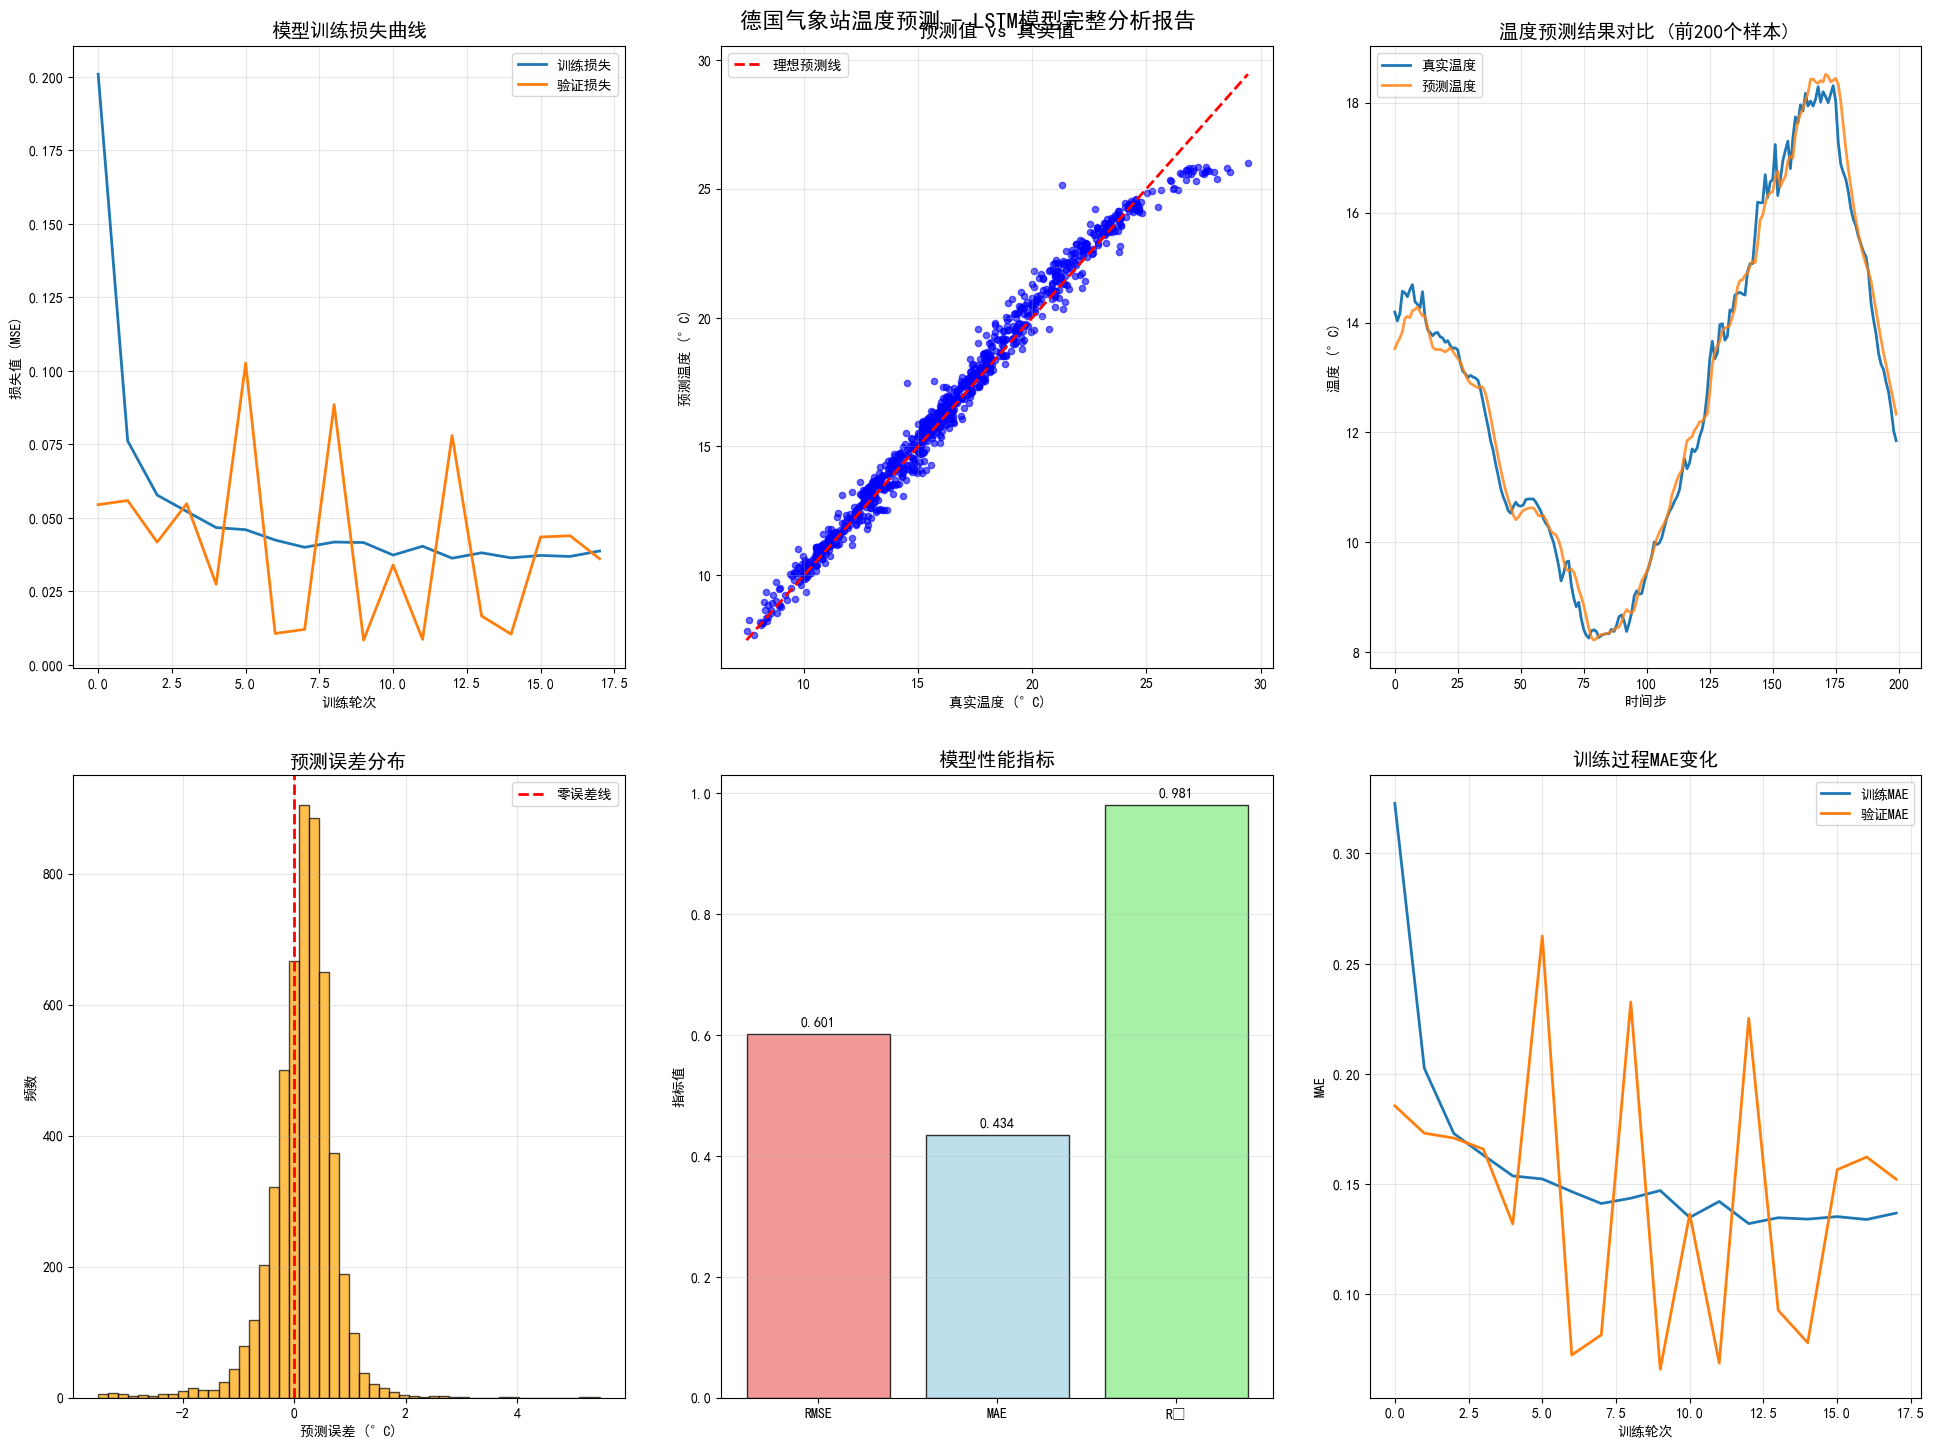


详细统计分析
平均绝对误差.........: 0.434 °C
均方根误差..........: 0.601 °C
R²得分...........: 0.981
最大正误差..........: 5.483 °C
最大负误差..........: -3.520 °C
平均误差...........: 0.146 °C
误差标准差..........: 0.583 °C

模型性能评估:
综合性能评级: 优秀

温度变化范围: 22.05 °C
RMSE相对于温度范围的比例: 2.7%
模型在温度变化范围内表现良好

训练历史摘要:
总训练轮次: 18
最终训练损失: 0.0387
最终验证损失: 0.0360
最终验证MAE: 0.1522

预测示例 (前5个测试样本):
真实温度 -> 预测温度 -> 误差
14.19°C -> 13.53°C -> -0.66°C
14.03°C -> 13.63°C -> -0.40°C
14.16°C -> 13.72°C -> -0.44°C
14.57°C -> 13.84°C -> -0.73°C
14.54°C -> 14.07°C -> -0.47°C


In [9]:
# 结果可视化
print("\n9. 生成结果图表")

# 进行预测
y_pred_scaled = model.predict(X_test)
y_pred_scaled = y_pred_scaled.flatten()

# 反标准化
def inverse_standardize(scaled_data, mean, std):    
    return scaled_data * std + mean
y_pred_original = inverse_standardize(y_pred_scaled, scaler_params['y_mean'], scaler_params['y_std'])
y_test_original = inverse_standardize(y_test, scaler_params['y_mean'], scaler_params['y_std'])

# 计算评估指标
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建综合图表
fig = plt.figure(figsize=(20, 15))

# 1. 训练历史损失曲线
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='训练损失', linewidth=2)
plt.plot(history.history['val_loss'], label='验证损失', linewidth=2)
plt.title('模型训练损失曲线', fontsize=14, fontweight='bold')
plt.xlabel('训练轮次')
plt.ylabel('损失值 (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 预测值与真实值对比散点图 - 修复这里
plt.subplot(2, 3, 2)
# 确保数据是一维的
y_test_flat = y_test_original.flatten()
y_pred_flat = y_pred_original.flatten()

# 如果数据点太多，可以采样显示
if len(y_test_flat) > 1000:
    # 随机采样1000个点避免过于密集
    indices = np.random.choice(len(y_test_flat), 1000, replace=False)
    y_test_sample = y_test_flat[indices]
    y_pred_sample = y_pred_flat[indices]
else:
    y_test_sample = y_test_flat
    y_pred_sample = y_pred_flat

plt.scatter(y_test_sample, y_pred_sample, alpha=0.6, c='blue', s=20)
max_val = max(y_test_sample.max(), y_pred_sample.max())
min_val = min(y_test_sample.min(), y_pred_sample.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='理想预测线')
plt.title('预测值 vs 真实值', fontsize=14, fontweight='bold')
plt.xlabel('真实温度 (°C)')
plt.ylabel('预测温度 (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 时间序列预测结果
plt.subplot(2, 3, 3)
# 只显示前200个测试样本以便清晰查看
show_samples = min(200, len(y_test_flat))
indices = range(show_samples)
plt.plot(indices, y_test_flat[:show_samples], label='真实温度', linewidth=2)
plt.plot(indices, y_pred_flat[:show_samples], label='预测温度', linewidth=2, alpha=0.8)
plt.title('温度预测结果对比 (前200个样本)', fontsize=14, fontweight='bold')
plt.xlabel('时间步')
plt.ylabel('温度 (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. 误差分布直方图
plt.subplot(2, 3, 4)
errors = y_pred_flat - y_test_flat
plt.hist(errors, bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='零误差线')
plt.title('预测误差分布', fontsize=14, fontweight='bold')
plt.xlabel('预测误差 (°C)')
plt.ylabel('频数')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. 模型评估指标对比
plt.subplot(2, 3, 5)
metrics = ['RMSE', 'MAE', 'R²']
values = [rmse, mae, r2]
colors = ['lightcoral', 'lightblue', 'lightgreen']
bars = plt.bar(metrics, values, color=colors, edgecolor='black', alpha=0.8)

# 在柱状图上添加数值标签
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title('模型性能指标', fontsize=14, fontweight='bold')
plt.ylabel('指标值')
plt.grid(True, alpha=0.3, axis='y')

# 6. 训练过程中的MAE变化或残差图
plt.subplot(2, 3, 6)
if 'mae' in history.history and 'val_mae' in history.history:
    plt.plot(history.history['mae'], label='训练MAE', linewidth=2)
    plt.plot(history.history['val_mae'], label='验证MAE', linewidth=2)
    plt.title('训练过程MAE变化', fontsize=14, fontweight='bold')
    plt.xlabel('训练轮次')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    # 如果没有MAE历史，显示残差图
    residuals = y_test_flat - y_pred_flat
    # 采样显示残差图避免数据点过多
    if len(residuals) > 1000:
        indices = np.random.choice(len(residuals), 1000, replace=False)
        y_pred_sample = y_pred_flat[indices]
        residuals_sample = residuals[indices]
    else:
        y_pred_sample = y_pred_flat
        residuals_sample = residuals
    
    plt.scatter(y_pred_sample, residuals_sample, alpha=0.6, c='purple', s=20)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title('残差图', fontsize=14, fontweight='bold')
    plt.xlabel('预测值')
    plt.ylabel('残差')
    plt.grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.suptitle('德国气象站温度预测 - LSTM模型完整分析报告', fontsize=16, fontweight='bold', y=0.98)
plt.show()

# 输出详细的统计信息
print("\n" + "="*60)
print("详细统计分析")
print("="*60)

# 误差统计
error_stats = {
    '平均绝对误差': f"{mae:.3f} °C",
    '均方根误差': f"{rmse:.3f} °C", 
    'R²得分': f"{r2:.3f}",
    '最大正误差': f"{errors.max():.3f} °C",
    '最大负误差': f"{errors.min():.3f} °C",
    '平均误差': f"{errors.mean():.3f} °C",
    '误差标准差': f"{errors.std():.3f} °C"
}

for stat, value in error_stats.items():
    print(f"{stat:.<15}: {value}")

# 模型性能评估
print("\n模型性能评估:")
if r2 >= 0.9:
    performance = "优秀"
elif r2 >= 0.7:
    performance = "良好" 
elif r2 >= 0.5:
    performance = "一般"
else:
    performance = "需要改进"

print(f"综合性能评级: {performance}")

# 温度预测范围分析
temp_range = y_test_flat.max() - y_test_flat.min()
relative_rmse = (rmse / temp_range) * 100

print(f"\n温度变化范围: {temp_range:.2f} °C")
print(f"RMSE相对于温度范围的比例: {relative_rmse:.1f}%")

if relative_rmse < 10:
    print("模型在温度变化范围内表现良好")
elif relative_rmse < 20:
    print("模型预测精度可以接受")
else:
    print("建议进一步优化模型")

# 显示训练历史摘要
print(f"\n训练历史摘要:")
print(f"总训练轮次: {len(history.history['loss'])}")
print(f"最终训练损失: {history.history['loss'][-1]:.4f}")
print(f"最终验证损失: {history.history['val_loss'][-1]:.4f}")

if 'val_mae' in history.history:
    print(f"最终验证MAE: {history.history['val_mae'][-1]:.4f}")

# 额外的预测示例
print(f"\n预测示例 (前5个测试样本):")
print("真实温度 -> 预测温度 -> 误差")
for i in range(min(5, len(y_test_flat))):
    true_temp = y_test_flat[i]
    pred_temp = y_pred_flat[i]
    error = pred_temp - true_temp
    print(f"{true_temp:.2f}°C -> {pred_temp:.2f}°C -> {error:+.2f}°C")